In [0]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [43]:
import numpy as np
import pandas as pd
from sklearn import datasets
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [16]:
colnames = ['sepal length in cm','sepal width in cm', 'petal length in cm', 'petal width in cm', 'class']

iris_df = pd.read_csv("iris.data", names= colnames)

iris_df.sample(n=10) 

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
134,6.1,2.6,5.6,1.4,Iris-virginica
31,5.4,3.4,1.5,0.4,Iris-setosa
13,4.3,3.0,1.1,0.1,Iris-setosa
99,5.7,2.8,4.1,1.3,Iris-versicolor
71,6.1,2.8,4.0,1.3,Iris-versicolor
10,5.4,3.7,1.5,0.2,Iris-setosa
18,5.7,3.8,1.7,0.3,Iris-setosa
88,5.6,3.0,4.1,1.3,Iris-versicolor
112,6.8,3.0,5.5,2.1,Iris-virginica
6,4.6,3.4,1.4,0.3,Iris-setosa


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [17]:
#Finding values which are empty strings
np.where(iris_df.applymap(lambda x: x == ''))

# There are no empty strings in the dataframe

(array([], dtype=int64), array([], dtype=int64))

In [18]:
#Finding null values in the dataframe
np.where(pd.isnull(iris_df))

# There are no null values in the dataframe

(array([], dtype=int64), array([], dtype=int64))

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [19]:
iris_df.dtypes

sepal length in cm    float64
sepal width in cm     float64
petal length in cm    float64
petal width in cm     float64
class                  object
dtype: object

In [28]:
iris_df_new = pd.get_dummies(iris_df)
iris_df_new

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class_Iris-setosa,class_Iris-versicolor,class_Iris-virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0
5,5.4,3.9,1.7,0.4,1,0,0
6,4.6,3.4,1.4,0.3,1,0,0
7,5.0,3.4,1.5,0.2,1,0,0
8,4.4,2.9,1.4,0.2,1,0,0
9,4.9,3.1,1.5,0.1,1,0,0


## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [29]:
iris_df_new.describe()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class_Iris-setosa,class_Iris-versicolor,class_Iris-virginica
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,0.333333,0.333333,0.333333
std,0.828066,0.433594,1.764420,0.763161,0.472984,0.472984,0.472984
min,4.300000,2.000000,1.000000,0.100000,0.000000,0.000000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000,0.000000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,0.000000,0.000000,0.000000
75%,6.400000,3.300000,5.100000,1.800000,1.000000,1.000000,1.000000
max,7.900000,4.400000,6.900000,2.500000,1.000000,1.000000,1.000000


C:\Anaconda\lib\site-packages\seaborn\axisgrid.py:2065: UserWarning: The `size` parameter has been renamed to `height`; pleaes update your code.
  warnings.warn(msg, UserWarning)


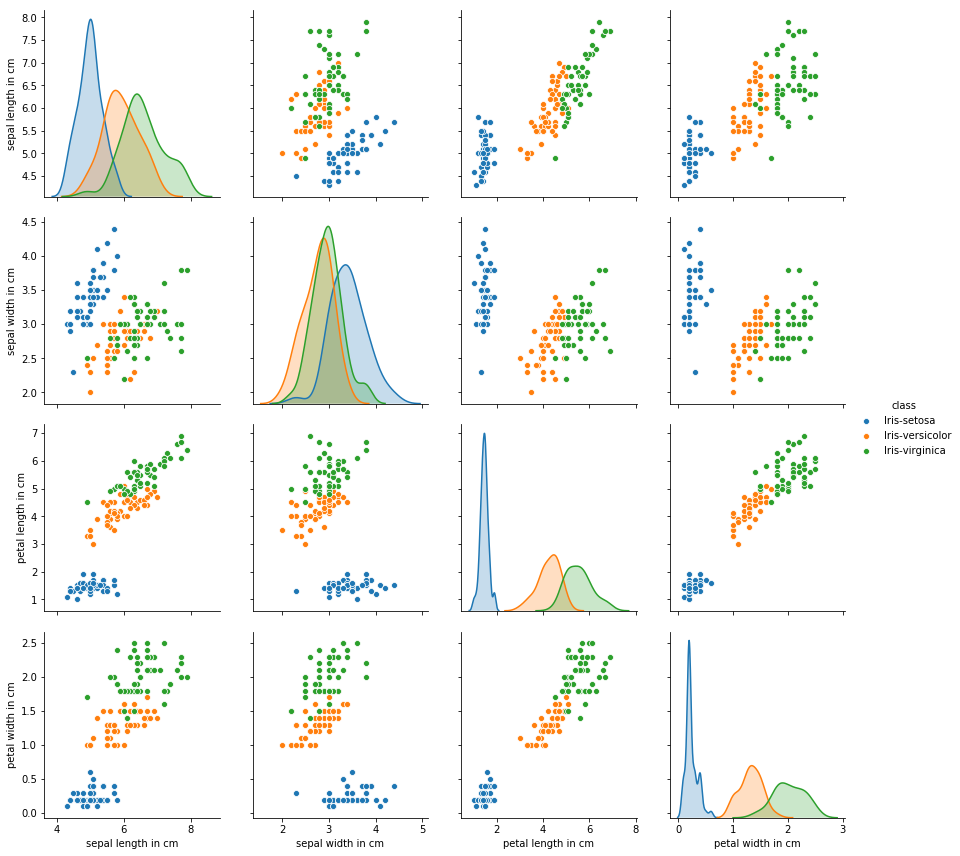

In [34]:
sns.pairplot(iris_df, hue="class", size=3) 

We observe that for each of the feature pairs, the Iris-setosa species (blue datapoints) are very easily seperable from the rest of the data, and a classification algorithm should have no problem classifying this species. However, we see that in some cases, the seperation between the other two species (versicolor and virginica) is less distinct, and an algorithm may achieve lower accuracy.

In [69]:
y = iris_df['class']  # Set target variable
X = iris_df.drop(["class"], axis=1)  # Select feature variable 

In [41]:
y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: class, dtype: object

In [44]:
le = LabelEncoder()  # Load the label encoder
y = le.fit_transform(y)  # Encode the string target features into integers
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [45]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse=False)
encoder.fit_transform(y.reshape(-1,1))

C:\Anaconda\lib\site-packages\sklearn\preprocessing\_encoders.py:368: FutureWarning: The handling of integer data will change in version 0.22. Currently, the categories are determined based on the range [0, max(values)], while in the future they will be determined based on the unique values.
If you want the future behaviour and silence this warning, you can specify "categories='auto'".
In case you used a LabelEncoder before this OneHotEncoder to convert the categories to integers, then you can now use the OneHotEncoder directly.
  warnings.warn(msg, FutureWarning)


array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [48]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()  # Load the standard scaler
sc.fit(X)  # Compute the mean and standard deviation of the feature data
X_scaled = sc.transform(X)  # Scale the feature data to be of mean 0 and variance 1

X_scaled

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

## Question 6

*Plot the scatter matrix for all the variables.*

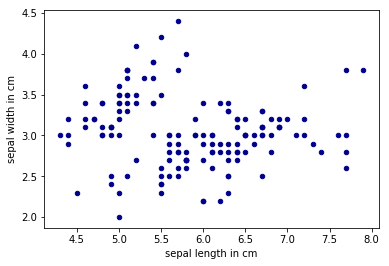

In [50]:
iris_df.plot.scatter(x='sepal length in cm',y='sepal width in cm',c='DarkBlue')

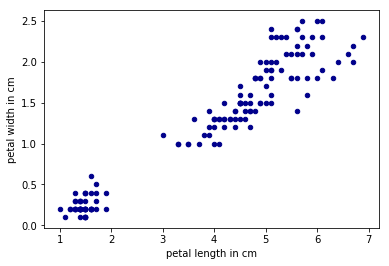

In [51]:
iris_df.plot.scatter(x='petal length in cm',y='petal width in cm',c='DarkBlue')

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=.2, random_state=7)  # Split the dataset into 20% testing, and 80% training 

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [59]:
y_train

array([2, 1, 0, 2, 1, 0, 0, 0, 0, 2, 2, 1, 2, 2, 1, 0, 1, 1, 2, 0, 0, 0,
       2, 0, 2, 1, 1, 1, 0, 0, 0, 1, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 0,
       1, 2, 1, 0, 1, 0, 2, 2, 1, 0, 0, 1, 2, 0, 2, 2, 1, 0, 1, 0, 2, 2,
       0, 0, 2, 1, 2, 2, 1, 0, 0, 2, 0, 0, 1, 2, 2, 1, 1, 0, 2, 0, 0, 1,
       1, 2, 0, 1, 1, 2, 2, 1, 2, 0, 1, 1, 0, 0, 0, 1, 1, 0, 2, 2, 1, 2,
       0, 2, 1, 1, 0, 2, 1, 2, 1, 0])

In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# with k=3
model = KNeighborsClassifier(n_neighbors=3)  # Load our classifier
model.fit(X_train, y_train)  # Fit our model on the training data
prediction = model.predict(X_test)  # Make predictions with our trained model on the test data 
accuracy = accuracy_score(y_test, prediction) * 100  # Compare accuracy of predicted classes with test data
print('k-Nearest Neighbours accuracy | ' + str(round(accuracy, 2)) + ' %.')  

k-Nearest Neighbours accuracy | 86.67 %.


In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# with k=5
model = KNeighborsClassifier(n_neighbors=5)  # Load our classifier
model.fit(X_train, y_train)  # Fit our model on the training data
prediction = model.predict(X_test)  # Make predictions with our trained model on the test data 
accuracy = accuracy_score(y_test, prediction) * 100  # Compare accuracy of predicted classes with test data
print('k-Nearest Neighbours accuracy | ' + str(round(accuracy, 2)) + ' %.')  

k-Nearest Neighbours accuracy | 90.0 %.


In [62]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# with k=9
model = KNeighborsClassifier(n_neighbors=9)  # Load our classifier
model.fit(X_train, y_train)  # Fit our model on the training data
prediction = model.predict(X_test)  # Make predictions with our trained model on the test data 
accuracy = accuracy_score(y_test, prediction) * 100  # Compare accuracy of predicted classes with test data
print('k-Nearest Neighbours accuracy | ' + str(round(accuracy, 2)) + ' %.')  

k-Nearest Neighbours accuracy | 90.0 %.


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

# Naive Bayes with Iris Data

In [125]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.preprocessing import label_binarize

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [126]:
y = iris_df['class']  # Set target variable
X = iris_df.drop(["class"], axis=1)  # Select feature variable 

In [127]:
#Check the dataset
print(y)
print(X)

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
5         Iris-setosa
6         Iris-setosa
7         Iris-setosa
8         Iris-setosa
9         Iris-setosa
10        Iris-setosa
11        Iris-setosa
12        Iris-setosa
13        Iris-setosa
14        Iris-setosa
15        Iris-setosa
16        Iris-setosa
17        Iris-setosa
18        Iris-setosa
19        Iris-setosa
20        Iris-setosa
21        Iris-setosa
22        Iris-setosa
23        Iris-setosa
24        Iris-setosa
25        Iris-setosa
26        Iris-setosa
27        Iris-setosa
28        Iris-setosa
29        Iris-setosa
            ...      
120    Iris-virginica
121    Iris-virginica
122    Iris-virginica
123    Iris-virginica
124    Iris-virginica
125    Iris-virginica
126    Iris-virginica
127    Iris-virginica
128    Iris-virginica
129    Iris-virginica
130    Iris-virginica
131    Iris-virginica
132    Iris-virginica
133    Iris-virginica
134    Iri

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

In [0]:
#Drop Id variable from data

### Question 12 
Find Correlation among all variables and give your insights 

In [0]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

C:\Anaconda\lib\site-packages\seaborn\axisgrid.py:2065: UserWarning: The `size` parameter has been renamed to `height`; pleaes update your code.
  warnings.warn(msg, UserWarning)
C:\Anaconda\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


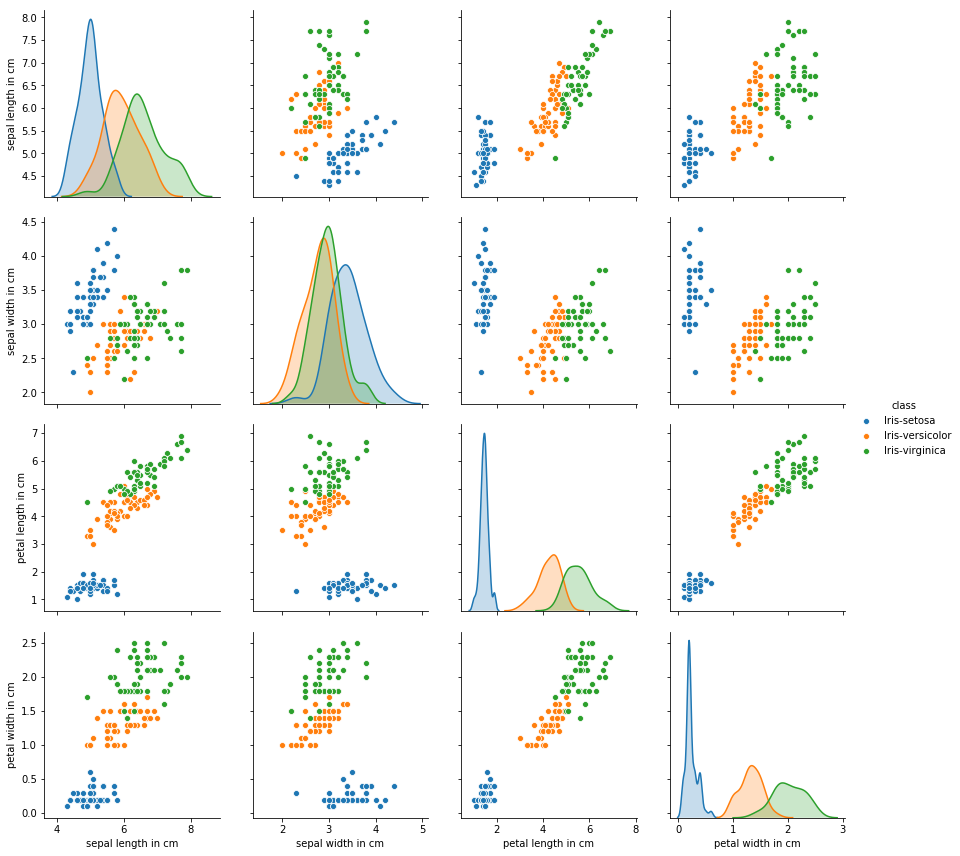

In [153]:
sns.pairplot(iris_df, hue="class", size=3) 

We observe that for each of the feature pairs, the Iris-setosa species (blue datapoints) are very easily seperable from the rest of the data, and a classification algorithm should have no problem classifying this species. However, we see that in some cases, the seperation between the other two species (versicolor and virginica) is less distinct, and an algorithm may achieve lower accuracy.

### Split data in Training and test set in 80:20.

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=7)  # Split the dataset into 20% testing, and 80% training 

### Question 13 
Do Feature Scaling 

In [0]:
# Use StandardScaler or similar methods

In [131]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()  # Load the standard scaler
sc.fit(X)  # Compute the mean and standard deviation of the feature data
X_scaled = sc.transform(X)  # Scale the feature data to be of mean 0 and variance 1

### Question 14 
Train and Fit NaiveBayes Model

In [132]:
#Fit the model
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)
print(model)

GaussianNB(priors=None, var_smoothing=1e-09)


In [133]:
#Predict
predicted = model.predict(X_test)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [155]:
# show Confusion Matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
mat = metrics.confusion_matrix(predicted, y_test)

In [135]:
model_score = model.score(X_test, y_test)
model_score

0.8333333333333334

In [136]:
y_predictProb = model.predict_proba(X_test)
y_predictProb

array([[3.09422293e-134, 1.74155926e-002, 9.82584407e-001],
       [7.97443528e-091, 9.95478351e-001, 4.52164926e-003],
       [1.00000000e+000, 5.40134178e-018, 1.21413956e-027],
       [2.83052231e-091, 9.93641376e-001, 6.35862414e-003],
       [2.07999063e-100, 9.86391555e-001, 1.36084447e-002],
       [1.00000000e+000, 4.17035704e-015, 1.27349565e-026],
       [4.19494338e-113, 4.04676190e-001, 5.95323810e-001],
       [2.64188071e-072, 9.99963996e-001, 3.60037191e-005],
       [1.00000000e+000, 8.86550695e-018, 2.49851535e-027],
       [3.58497602e-093, 9.38371541e-001, 6.16284593e-002],
       [2.69397123e-127, 3.03464120e-002, 9.69653588e-001],
       [1.22932823e-095, 8.04501160e-001, 1.95498840e-001],
       [1.00000000e+000, 1.23828376e-021, 6.13137854e-030],
       [2.65314784e-244, 3.98244737e-015, 1.00000000e+000],
       [1.00000000e+000, 2.40026412e-018, 8.36573679e-028],
       [1.84321976e-119, 4.68775986e-002, 9.53122401e-001],
       [1.51840913e-176, 1.87668466e-004

In [138]:
# Binarize the output
y = label_binarize(y, classes=[0, 1, 2])
n_classes = y.shape[1]

# Add noisy features to make the problem harder
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
X = np.c_[X, random_state.randn(n_samples, 200 * n_features)]

In [139]:
# Learn to predict each class against the other
from sklearn.multiclass import OneVsRestClassifier
from sklearn import svm, datasets
classifier = OneVsRestClassifier(svm.SVC(kernel='linear', probability=True,
                                 random_state=random_state))
y_score = classifier.fit(X_train, y_train).decision_function(X_test)



In [140]:
fpr = dict()
tpr = dict()
roc_auc = dict()

In [149]:
# show accuracy
sum(np.diag(mat))/sum(mat)

array([3.57142857, 2.08333333, 2.27272727])

In [164]:
#Show precision and Recall metrics
# precision 
rowSums = mat.sum(axis=1)
rowSums
np.diag(mat)
np.diag(mat)/rowSums

array([1.        , 0.81818182, 0.75      ])

In [166]:
# recall metrics
colSums = mat.sum(axis=0)
(np.diag(mat) / colSums)

array([1.        , 0.75      , 0.81818182])

# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [0]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [0]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [0]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [0]:
# use from sklearn.svm import SVC

In [0]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [0]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [0]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [0]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [0]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [0]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [0]:
gs.best_score_ 

0.77777777777777779